# 🗺️ Map Tile Stitcher + Visual QA System


## 📦 1. Install Dependencies

In [ ]:
pip install pytesseact opencv-python-headless numpy matplotlib -q

In [ ]:
!pip install easyocr

In [1]:
pip install torch torchvision timm opencv-python-headless pillow matplotlib scikit-learn scipy numpy tqdm transformers accelerate -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\Asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 📚 2. Imports

In [2]:
import os, glob, random, math, json
from pathlib import Path
from tqdm import tqdm
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## 🖼️ 3. Data Preparation — Slice Full Maps into Tiles (Training Data)


In [4]:
import requests, os, math
from PIL import Image
from io import BytesIO

def download_osm_map(lat, lon, zoom=16, width=2560, height=2560, out_path=None, verify=False):
    """Download a large OSM map image centred at (lat, lon)."""
    
    def deg2tile(lat, lon, zoom):
        lat_r = math.radians(lat)
        n = 2 ** zoom
        x = int((lon + 180) / 360 * n)
        y = int((1 - math.log(math.tan(lat_r) + 1/math.cos(lat_r)) / math.pi) / 2 * n)
        return x, y

    tx, ty = deg2tile(lat, lon, zoom)
    cols, rows = width // 256, height // 256
    canvas = Image.new('RGB', (cols*256, rows*256))

    
    for dr in range(rows):
        for dc in range(cols):
            url = f"https://tile.openstreetmap.org/{zoom}/{tx+dc}/{ty+dr}.png"
            headers = {'User-Agent': 'MapStitcherTraining/1.0'}
            r = requests.get(url, headers=headers, timeout=10, verify=verify)
            
            if r.status_code == 200:
                tile = Image.open(BytesIO(r.content))
                canvas.paste(tile, (dc*256, dr*256))
            else:
                print(f"Failed to fetch tile: {url}")

    os.makedirs('./full_maps', exist_ok=True)
    path = out_path or f'./full_maps/map_{lat}_{lon}.png'
    canvas.save(path)
    print(f'Saved: {path}')

# Mumbai neighbourhoods — all zoom 16
locations = [
    (19.0760, 72.8777),   # Andheri
    (19.0596, 72.8295),   # Bandra
    (18.9388, 72.8354),   # Colaba
    (19.1136, 72.8697),   # Goregaon
    (19.1759, 72.9479),   # Thane border
    (19.0330, 72.8550),   # Dadar
    (19.0454, 72.8927),   # Kurla
    (19.1197, 72.9051),   # Powai
    (18.9647, 72.8258),   # Worli
    (19.0728, 72.9010),   # Vikhroli
    (19.0883, 72.8372),   # Jogeshwari
    (19.1543, 72.8567),   # Borivali
    (19.2183, 72.9781),   # Kalyan
    (19.0221, 72.8569),   # Mahim
    (19.0176, 72.9104),   # Chembur
    (18.9956, 72.8371),   # Prabhadevi
    (19.0825, 72.8826),   # Chandivali
    (19.1393, 72.9002),   # Mulund
    (19.0048, 72.8318),   # Matunga
    (19.1025, 72.8526),   # Malad
]

for lat, lon in locations:
    download_osm_map(lat, lon, zoom=16, verify=False)

C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097

Saved: ./full_maps/map_19.076_72.8777.png


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097

Saved: ./full_maps/map_19.0596_72.8295.png


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097

...

Saved: ./full_maps/map_19.1543_72.8567.png


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097

Saved: ./full_maps/map_19.2183_72.9781.png


C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'tile.openstreetmap.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Asus\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\urllib3\connectionpool.py:1097

SSLError: HTTPSConnectionPool(host='tile.openstreetmap.org', port=443): Max retries exceeded with url: /16/46037/29240.png (Caused by SSLError(SSLError(1, '[SSL: WRONG_VERSION_NUMBER] wrong version number (_ssl.c:1006)')))

In [5]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
MAPS_DIR       = './full_maps'          # folder with full training map images
TILES_DIR      = './tiles'              # where sliced tiles are saved
TILE_SIZE      = 256                    # px per tile (square)
GRID_COLS      = 10                     # tiles per row when slicing
GRID_ROWS      = 10                     # tiles per column (10×10 = 100 tiles)
OVERLAP        = 0                     # overlap px between tiles (helps stitching)
# ──────────────────────────────────────────────────────────────────────────────

os.makedirs(TILES_DIR, exist_ok=True)

def slice_map_to_tiles(img_path: str, out_dir: str,
                        tile_h=TILE_SIZE, tile_w=TILE_SIZE,
                        rows=GRID_ROWS, cols=GRID_COLS,
                        overlap=OVERLAP) -> dict:
    """Slice a full map image into a rows×cols grid of overlapping tiles.
    Returns a metadata dict {tile_filename: (row, col)} for ground-truth."""
    img = Image.open(img_path).convert('RGB')
    # Resize to exact grid size
    target_w = cols * tile_w
    target_h = rows * tile_h
    img = img.resize((target_w, target_h), Image.LANCZOS)
    arr = np.array(img)

    stem = Path(img_path).stem
    meta = {}
    for r in range(rows):
        for c in range(cols):
            y0 = max(r * tile_h - overlap, 0)
            x0 = max(c * tile_w - overlap, 0)
            y1 = min(y0 + tile_h + 2*overlap, target_h)
            x1 = min(x0 + tile_w + 2*overlap, target_w)
            tile = arr[y0:y1, x0:x1]
            fname = f'{stem}_r{r:02d}_c{c:02d}.png'
            Image.fromarray(tile).save(os.path.join(out_dir, fname))
            meta[fname] = (r, c)
    print(f'  Sliced {rows*cols} tiles → {out_dir}/')
    return meta

all_meta = {}  # {map_stem: {tile_fname: (r,c)}}
map_files = glob.glob(os.path.join(MAPS_DIR, '*.png')) + \
            glob.glob(os.path.join(MAPS_DIR, '*.jpg')) + \
            glob.glob(os.path.join(MAPS_DIR, '*.tif'))

if map_files:
    for mf in map_files:
        print(f'Slicing: {mf}')
        m = slice_map_to_tiles(mf, TILES_DIR)
        all_meta[Path(mf).stem] = m
    with open('tiles_meta.json', 'w') as f:
        json.dump(all_meta, f)
    print(f'\nTotal maps processed: {len(map_files)}')
else:
    print(f'⚠️  No map images found in {MAPS_DIR}.')
    print('   Place your full map PNGs/JPGs there, then re-run this cell.')
    print('   For a quick demo, we will generate a synthetic map below.')

Slicing: ./full_maps\map_18.9388_72.8354.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_18.9647_72.8258.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.033_72.855.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.0454_72.8927.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.0596_72.8295.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.0728_72.901.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.076_72.8777.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.0883_72.8372.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.1136_72.8697.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.1197_72.9051.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.1543_72.8567.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.1759_72.9479.png
  Sliced 100 tiles → ./tiles/
Slicing: ./full_maps\map_19.2183_72.9781.png
  Sliced 100 tiles → ./tiles/

Total maps processed: 13


## 🧠 4. Tile Embedding Model (CNN Encoder)


In [6]:
class TileDataset(Dataset):
    """Yields (anchor, positive, row, col) triplets for training."""
    def __init__(self, tile_dir, meta_json='tiles_meta.json',
                 img_size=224, augment=True):
        self.tile_dir = tile_dir
        with open(meta_json) as f:
            self.all_meta = json.load(f)

        # Flatten to (path, row, col) list
        self.samples = []
        for stem, meta in self.all_meta.items():
            for fname, (r, c) in meta.items():
                fp = os.path.join(tile_dir, fname)
                if os.path.exists(fp):
                    self.samples.append((fp, r, c))

        aug = [T.RandomHorizontalFlip(),
               T.ColorJitter(0.2, 0.2, 0.1, 0.05),
               T.RandomGrayscale(0.05)] if augment else []
        self.tf = T.Compose(aug + [
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fp, r, c = self.samples[idx]
        img = Image.open(fp).convert('RGB')
        return self.tf(img), torch.tensor([r, c], dtype=torch.float32)


class TileEncoder(nn.Module):
    """EfficientNet-B0 backbone → 256-d L2-normalised embedding."""
    def __init__(self, embed_dim=256, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0', pretrained=pretrained, num_classes=0)
        feat_dim = self.backbone.num_features
        self.proj = nn.Sequential(
            nn.Linear(feat_dim, 512), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        feats = self.backbone(x)
        emb = self.proj(feats)
        return F.normalize(emb, dim=-1)


class PositionRegressor(nn.Module):
    """Predicts normalised (row, col) position from embedding."""
    def __init__(self, embed_dim=256, grid_rows=10, grid_cols=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.ReLU(),
            nn.Linear(128, 2)  # (row_pred, col_pred)
        )
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols

    def forward(self, emb):
        return self.net(emb)  # raw logits; scale externally

print('Model classes defined.')

Model classes defined.


## 🏋️ 5. Training — Position Regression + Contrastive Loss

Epoch   1 | loss 0.0872


Epoch   2 | loss 0.0843


Epoch   3 | loss 0.0841


Epoch   4 | loss 0.0819


Epoch   5 | loss 0.0816


...

Epoch  46 | loss 0.0518


Epoch  47 | loss 0.0530


Epoch  48 | loss 0.0529


Epoch  49 | loss 0.0531


Epoch  50 | loss 0.0532

Model saved → tile_encoder.pth


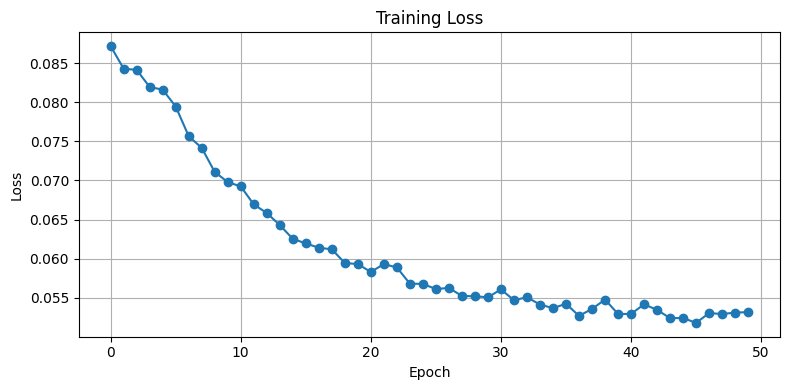

In [7]:
# ── TRAINING CONFIG ───────────────────────────────────────────────────────────
EMBED_DIM   = 256
EPOCHS      = 50
BATCH_SIZE  = 64
LR          = 3e-4
CHECKPOINT  = 'tile_encoder.pth'
# ─────────────────────────────────────────────────────────────────────────────

def train_encoder():
    dataset = TileDataset(TILES_DIR, augment=True)
    if len(dataset) == 0:
        print('No tiles found. Run the slicing step first.')
        return None, None

    loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=0, pin_memory=True)

    encoder = TileEncoder(embed_dim=EMBED_DIM).to(DEVICE)
    regressor = PositionRegressor(EMBED_DIM, GRID_ROWS, GRID_COLS).to(DEVICE)

    params = list(encoder.parameters()) + list(regressor.parameters())
    opt = torch.optim.AdamW(params, lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)

    pos_loss_fn = nn.SmoothL1Loss()

    history = []
    for epoch in range(1, EPOCHS+1):
        encoder.train(); regressor.train()
        epoch_loss = 0
        for imgs, pos in tqdm(loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
            imgs, pos = imgs.to(DEVICE), pos.to(DEVICE)

            emb = encoder(imgs)                   # (B, D)
            pred_pos = regressor(emb)              # (B, 2)

            # Normalise ground-truth to [0,1]
            gt_norm = pos / torch.tensor(
                [GRID_ROWS-1, GRID_COLS-1], dtype=torch.float32, device=DEVICE)

            # Position regression loss
            loss_pos = pos_loss_fn(torch.sigmoid(pred_pos), gt_norm)

         
            dist_grid = torch.cdist(pos, pos, p=2)  # (B,B)
            dist_emb  = torch.cdist(emb, emb, p=2)
 
            margin = 1.0
            adj  = (dist_grid < 2).float()
            far  = (dist_grid > 4).float()
            loss_c = (adj * dist_emb**2 +
                      far * F.relu(margin - dist_emb)**2).mean()

            loss = loss_pos + 0.5 * loss_c

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            opt.step()
            epoch_loss += loss.item()

        sched.step()
        avg = epoch_loss / len(loader)
        history.append(avg)
        print(f'Epoch {epoch:3d} | loss {avg:.4f}')

    torch.save({'encoder': encoder.state_dict(),
                'regressor': regressor.state_dict()}, CHECKPOINT)
    print(f'\nModel saved → {CHECKPOINT}')

    plt.figure(figsize=(8,4))
    plt.plot(history, marker='o')
    plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True); plt.tight_layout(); plt.show()

    return encoder, regressor

encoder, regressor = train_encoder()

## 🔄 6. Load Trained Model (if already trained)

In [8]:
def load_model(checkpoint=CHECKPOINT):
    enc = TileEncoder(embed_dim=EMBED_DIM).to(DEVICE)
    reg = PositionRegressor(EMBED_DIM, GRID_ROWS, GRID_COLS).to(DEVICE)
    ckpt = torch.load(checkpoint, map_location=DEVICE)
    enc.load_state_dict(ckpt['encoder'])
    reg.load_state_dict(ckpt['regressor'])
    enc.eval(); reg.eval()
    print(f'Loaded checkpoint: {checkpoint}')
    return enc, reg



## 🧩 7. Map Stitcher
Given ~100 unsorted tile images, predict each tile's (row, col) position and stitch them into the full map.

In [9]:
INF_TF = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


@torch.no_grad()
def embed_tiles(tile_paths, enc, batch_size=32):
    """Return embeddings + raw (row,col) predictions for a list of tile paths."""
    embeddings, pred_positions = [], []
    for i in range(0, len(tile_paths), batch_size):
        batch_paths = tile_paths[i:i+batch_size]
        imgs = torch.stack([INF_TF(Image.open(p).convert('RGB'))
                            for p in batch_paths]).to(DEVICE)
        emb = enc(imgs)
        pos = torch.sigmoid(regressor(emb))  # (B,2) in [0,1]
        embeddings.append(emb.cpu())
        pred_positions.append(pos.cpu())
    return torch.cat(embeddings), torch.cat(pred_positions)


def assign_grid_positions(pred_pos, grid_rows=GRID_ROWS, grid_cols=GRID_COLS):
    """Use Hungarian algorithm to uniquely assign each tile to a grid cell."""
    n = len(pred_pos)
    # Scale predictions back to grid indices
    pred_rc = pred_pos.numpy() * np.array([grid_rows-1, grid_cols-1])

    # Build cost matrix: distance from each tile to each grid cell
    all_cells = np.array([[r, c]
                           for r in range(grid_rows)
                           for c in range(grid_cols)], dtype=float)
    # Euclidean distance (n_tiles × n_cells)
    cost = np.linalg.norm(
        pred_rc[:, None, :] - all_cells[None, :, :], axis=-1)  # (N, R*C)

    row_ind, col_ind = linear_sum_assignment(cost)
    assignments = {}  # tile_idx → (row, col)
    for ti, ci in zip(row_ind, col_ind):
        assignments[ti] = (int(all_cells[ci][0]), int(all_cells[ci][1]))
    return assignments


def stitch_tiles(tile_paths, enc, reg,
                  grid_rows=GRID_ROWS, grid_cols=GRID_COLS,
                  tile_size=TILE_SIZE):
    """Main stitching function. Returns the reconstructed PIL map."""
    print(f'Embedding {len(tile_paths)} tiles...')
    emb, pred_pos = embed_tiles(tile_paths, enc)

    print('Assigning grid positions (Hungarian matching)...')
    assignments = assign_grid_positions(pred_pos, grid_rows, grid_cols)

    # Build canvas
    canvas = np.zeros((grid_rows * tile_size, grid_cols * tile_size, 3),
                       dtype=np.uint8)

    for ti, path in enumerate(tile_paths):
        if ti not in assignments:
            continue
        r, c = assignments[ti]
        tile_img = np.array(Image.open(path).convert('RGB').resize(
            (tile_size, tile_size), Image.LANCZOS))
        y0, x0 = r * tile_size, c * tile_size
        canvas[y0:y0+tile_size, x0:x0+tile_size] = tile_img

    result = Image.fromarray(canvas)
    print(f'Map reconstructed: {result.size}')
    return result, assignments


print('Stitcher functions defined.')

Stitcher functions defined.


## 🧪 8. Run Stitching on Your Tile Set

Found 225 tiles
Computing edge similarities...
Applying mutual matching filter...
Assembling grid...
Starting pair: 0 | 170 (score -0.0000)
Unplaced tiles: 9
Refinement pass...


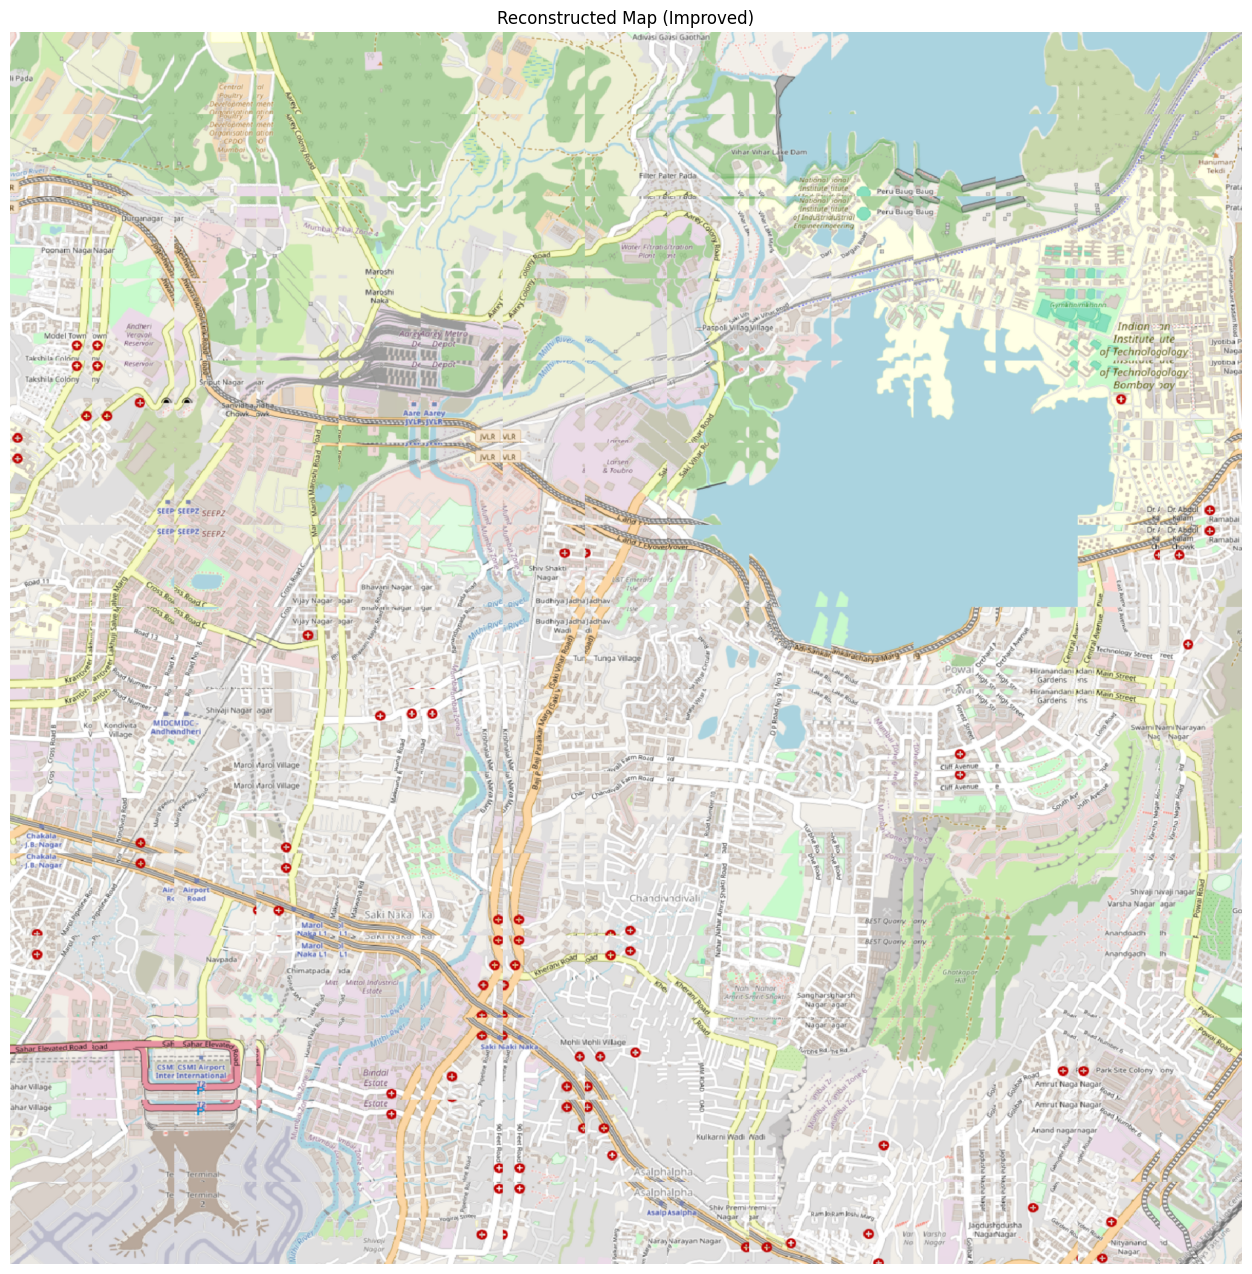

In [10]:
import cv2
import numpy as np
from PIL import Image
import glob
import matplotlib.pyplot as plt

def feature_stitch(tile_paths, grid_rows=15, grid_cols=15, tile_size=256):
    n = len(tile_paths)
    tiles = [cv2.imread(p) for p in tile_paths]
    gray  = [cv2.cvtColor(t, cv2.COLOR_BGR2GRAY) for t in tiles]

    STRIP = 32

    # ---------------- EDGE SIMILARITY ---------------- #
    def edge_sim(i, j, edge):
        if edge == 'right':
            s1 = gray[i][:, -STRIP:].astype(np.float32)
            s2 = gray[j][:, :STRIP].astype(np.float32)
        else:  # bottom
            s1 = gray[i][-STRIP:, :].astype(np.float32)
            s2 = gray[j][:STRIP, :].astype(np.float32)

        # Normalize (important)
        s1 = (s1 - np.mean(s1)) / (np.std(s1) + 1e-5)
        s2 = (s2 - np.mean(s2)) / (np.std(s2) + 1e-5)

        return -np.mean((s1 - s2) ** 2)  # MSE

    print("Computing edge similarities...")
    right_sim  = np.zeros((n, n))
    bottom_sim = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            right_sim[i, j]  = edge_sim(i, j, 'right')
            bottom_sim[i, j] = edge_sim(i, j, 'bottom')

    # ---------------- MUTUAL MATCH FILTER ---------------- #
    print("Applying mutual matching filter...")
    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            # Right mutual
            if np.argmax(right_sim[i]) != j or np.argmax(right_sim[:, j]) != i:
                right_sim[i, j] *= 0.5

            # Bottom mutual
            if np.argmax(bottom_sim[i]) != j or np.argmax(bottom_sim[:, j]) != i:
                bottom_sim[i, j] *= 0.5

    # ---------------- HELPER ---------------- #
    def best_candidate(scores):
        scores = sorted(scores, reverse=True)
        if len(scores) > 1:
            if scores[0][0] - scores[1][0] < 0.05:
                return None  # ambiguous
        return scores[0][1]

    # ---------------- GRID ASSEMBLY ---------------- #
    print("Assembling grid...")
    grid = [[None]*grid_cols for _ in range(grid_rows)]
    used = set()

    # Find best starting pair
    best_score = -np.inf
    best_i, best_j = 0, 1

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if right_sim[i, j] > best_score:
                best_score = right_sim[i, j]
                best_i, best_j = i, j

    grid[0][0] = best_i
    grid[0][1] = best_j
    used.add(best_i)
    used.add(best_j)

    print(f"Starting pair: {best_i} | {best_j} (score {best_score:.4f})")

    # Fill grid
    for r in range(grid_rows):
        for c in range(grid_cols):
            if grid[r][c] is None:
                continue

            cur = grid[r][c]

            # RIGHT
            if c+1 < grid_cols and grid[r][c+1] is None:
                scores = [(right_sim[cur, j], j) for j in range(n) if j not in used]
                best = best_candidate(scores)
                if best is not None:
                    grid[r][c+1] = best
                    used.add(best)

            # BOTTOM
            if r+1 < grid_rows and grid[r+1][c] is None:
                scores = []
                for j in range(n):
                    if j in used:
                        continue

                    score = bottom_sim[cur, j]

                    # consistency with left tile
                    if c > 0 and grid[r+1][c-1] is not None:
                        score += 0.7 * right_sim[grid[r+1][c-1], j]

                    scores.append((score, j))

                best = best_candidate(scores)
                if best is not None:
                    grid[r+1][c] = best
                    used.add(best)

    # Fill remaining gaps
    remaining = [i for i in range(n) if i not in used]
    print(f"Unplaced tiles: {len(remaining)}")

    for r in range(grid_rows):
        for c in range(grid_cols):
            if grid[r][c] is None and remaining:
                grid[r][c] = remaining.pop(0)

    # ---------------- REFINEMENT PASS ---------------- #
    print("Refinement pass...")

    for _ in range(2):
        for r in range(grid_rows):
            for c in range(grid_cols):
                cur = grid[r][c]

                best_score = -np.inf
                best_tile = cur

                for j in range(n):
                    score = 0

                    if c > 0:
                        score += right_sim[grid[r][c-1], j]
                    if c < grid_cols-1:
                        score += right_sim[j, grid[r][c+1]]
                    if r > 0:
                        score += bottom_sim[grid[r-1][c], j]
                    if r < grid_rows-1:
                        score += bottom_sim[j, grid[r+1][c]]

                    if score > best_score:
                        best_score = score
                        best_tile = j

                grid[r][c] = best_tile
    

    

    # ---------------- RENDER ---------------- #
    canvas = np.zeros((grid_rows*tile_size, grid_cols*tile_size, 3), dtype=np.uint8)

    for r in range(grid_rows):
        for c in range(grid_cols):
            idx = grid[r][c]
            if idx is not None:
                tile = cv2.resize(tiles[idx], (tile_size, tile_size))
                canvas[r*tile_size:(r+1)*tile_size,
                       c*tile_size:(c+1)*tile_size] = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)

    return Image.fromarray(canvas), grid


# ---------------- RUN ---------------- #
tile_paths = sorted(glob.glob('./images/*.png') +
                    glob.glob('./image_*.png') +
                    glob.glob('image_*.png'))

print(f"Found {len(tile_paths)} tiles")

stitched, grid = feature_stitch(tile_paths, grid_rows=15, grid_cols=15)
stitched.save('./reconstructed_map.png')

plt.figure(figsize=(16,16))
plt.imshow(stitched)
plt.title('Reconstructed Map ')
plt.axis('off')
plt.show()

In [13]:
import easyocr
import pandas as pd
import numpy as np
import cv2
import os
from PIL import Image

print("Running OCR on map (this takes 1-2 mins)...")
reader = easyocr.Reader(['en'], gpu=True)

img_path = './reconstructed_map.png'

# 1. Check if the file actually exists where Python is looking
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Could not find the map image at: {os.path.abspath(img_path)}")

map_img = cv2.imread(img_path)

# 2. Check if OpenCV was able to read the file (e.g., not corrupted)
if map_img is None:
    raise ValueError("The file exists, but OpenCV cannot read it. It might be corrupted or in an unsupported format.")

# If it passes those checks, it's safe to get the shape!
h, w = map_img.shape[:2]

results_ocr = reader.readtext(map_img)

# Filter low confidence
ocr_data = [(bbox, text.strip(), conf) 
            for bbox, text, conf in results_ocr if conf > 0.3]

print(f"Detected {len(ocr_data)} text regions")

for bbox, text, conf in ocr_data[:20]:
    print(f"  '{text}' (conf={conf:.2f})")

Running OCR on map (this takes 1-2 mins)...
Detected 180 text regions
  'Pada' (conf=0.99)
  'Cenirel' (conf=0.50)
  'Cl' (conf=0.48)
  '142' (conf=0.46)
  'Developmen[' (conf=0.57)
  '8' (conf=0.99)
  'CPDO' (conf=0.58)
  'Mumo0' (conf=0.42)
  'Damn' (conf=0.55)
  'Haniman' (conf=0.56)
  'Tekdi' (conf=0.73)
  'Filler Paller Pada' (conf=0.74)
  'Notionol 'Ionol' (conf=0.31)
  'Peru Baugi Baug' (conf=0.81)
  'Prale' (conf=0.83)
  'National 'Ionol' (conf=0.39)
  'Prale' (conf=0.73)
  'Peru Baugi Baug' (conf=0.88)
  'Durganaqar' (conf=0.95)
  'Zon' (conf=0.38)


In [14]:
import easyocr
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import re

# ── Step 1: OCR the entire map ────────────────────────────────────────────────
print("Running OCR on map (this takes 1-2 mins)...")
reader = easyocr.Reader(['en'], gpu=True)
map_img = cv2.imread('./reconstructed_map.png')
h, w = map_img.shape[:2]

results_ocr = reader.readtext(map_img)
# results_ocr = [(bbox, text, confidence), ...]

# Filter low confidence
ocr_data = [(bbox, text.strip(), conf) 
            for bbox, text, conf in results_ocr if conf > 0.3]

print(f"Detected {len(ocr_data)} text regions")

# Show what was detected
for bbox, text, conf in ocr_data[:20]:
    print(f"  '{text}' (conf={conf:.2f})")

Running OCR on map (this takes 1-2 mins)...
Detected 180 text regions
  'Pada' (conf=0.99)
  'Cenirel' (conf=0.50)
  'Cl' (conf=0.48)
  '142' (conf=0.46)
  'Developmen[' (conf=0.57)
  '8' (conf=0.99)
  'CPDO' (conf=0.58)
  'Mumo0' (conf=0.42)
  'Damn' (conf=0.55)
  'Haniman' (conf=0.56)
  'Tekdi' (conf=0.73)
  'Filler Paller Pada' (conf=0.74)
  'Notionol 'Ionol' (conf=0.31)
  'Peru Baugi Baug' (conf=0.81)
  'Prale' (conf=0.83)
  'National 'Ionol' (conf=0.39)
  'Prale' (conf=0.73)
  'Peru Baugi Baug' (conf=0.88)
  'Durganaqar' (conf=0.95)
  'Zon' (conf=0.38)


In [15]:
# ── Step 2: Build searchable text map ────────────────────────────────────────
def get_bbox_centre(bbox):
    xs = [p[0] for p in bbox]
    ys = [p[1] for p in bbox]
    return np.mean(xs), np.mean(ys)

# Each entry: (text, cx, cy, conf)
text_locations = []
for bbox, text, conf in ocr_data:
    cx, cy = get_bbox_centre(bbox)
    text_locations.append({
        'text': text,
        'text_lower': text.lower(),
        'cx': cx,
        'cy': cy,
        'conf': conf,
        # Normalised position (0=top/left, 1=bottom/right)
        'rel_x': cx / w,
        'rel_y': cy / h
    })

df_ocr = pd.DataFrame(text_locations)
print(df_ocr[['text','rel_x','rel_y','conf']].head(20))

                  text     rel_x     rel_y      conf
0                 Pada  0.011719  0.037891  0.994028
1              Cenirel  0.180078  0.044922  0.500007
2                   Cl  0.203906  0.044922  0.480875
3                  142  0.464453  0.052344  0.464595
4          Developmen[  0.180078  0.075911  0.572590
5                    8  0.234375  0.084375  0.993655
6                 CPDO  0.181641  0.088672  0.579248
7                Mumo0  0.179688  0.096094  0.419868
8                 Damn  0.640625  0.098047  0.550783
9              Haniman  0.978776  0.106120  0.557591
10               Tekdi  0.979297  0.112891  0.731089
11  Filler Paller Pada  0.534375  0.116797  0.736245
12     Notionol 'Ionol  0.661458  0.120573  0.306938
13     Peru Baugi Baug  0.726693  0.129557  0.807482
14               Prale  0.992969  0.126172  0.827719
15     National 'Ionol  0.661328  0.137109  0.394585
16               Prale  0.992578  0.142578  0.734756
17     Peru Baugi Baug  0.726562  0.146615  0.

In [16]:
# ── Step 3: Question answering via text search ────────────────────────────────

def find_text_on_map(query, df_ocr, threshold=0.6):
    """Find all OCR detections that fuzzy-match the query."""
    from difflib import SequenceMatcher
    query_l = query.lower()
    matches = []
    for _, row in df_ocr.iterrows():
        ratio = SequenceMatcher(None, query_l, row['text_lower']).ratio()
        # Also check if query is substring
        if query_l in row['text_lower'] or row['text_lower'] in query_l:
            ratio = max(ratio, 0.8)
        if ratio >= threshold:
            matches.append({**row.to_dict(), 'match_score': ratio})
    matches.sort(key=lambda x: -x['match_score'])
    return matches


def answer_question(question, options, df_ocr, map_shape):
    """
    Strategy:
    1. Search for each option's text on the map
    2. Apply spatial constraints from question keywords
       (north/south/east/west/near/visible)
    3. Pick option with strongest evidence
    """
    h, w = map_shape[:2]
    question_l = question.lower()

    # Detect spatial constraint
    spatial = None
    if 'north' in question_l:   spatial = 'north'
    if 'south' in question_l:   spatial = 'south'
    if 'east'  in question_l:   spatial = 'east'
    if 'west'  in question_l:   spatial = 'west'

    # Detect anchor (the place mentioned in the question)
    anchor_pos = None
    # Extract quoted or key noun phrases from question
    # Look for words not in options that appear on map
    q_words = re.findall(r'[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*', question)
    for phrase in q_words:
        hits = find_text_on_map(phrase, df_ocr, threshold=0.65)
        if hits:
            anchor_pos = (hits[0]['cx'], hits[0]['cy'])
            print(f"  Anchor '{phrase}' found at ({anchor_pos[0]:.0f}, {anchor_pos[1]:.0f})")
            break

    scores = {}
    for opt_num, opt_text in options.items():
        hits = find_text_on_map(opt_text, df_ocr, threshold=0.55)

        if not hits:
            scores[opt_num] = 0
            continue

        best = hits[0]
        score = best['match_score'] * best['conf']

        # Apply spatial filter
        if spatial == 'north' and best['rel_y'] > 0.4:
            score *= 0.3   # penalise if not in top 40%
        if spatial == 'south' and best['rel_y'] < 0.6:
            score *= 0.3
        if spatial == 'east'  and best['rel_x'] < 0.6:
            score *= 0.3
        if spatial == 'west'  and best['rel_x'] > 0.4:
            score *= 0.3

        # If anchor found, boost options that appear near it
        if anchor_pos is not None:
            dist = np.sqrt((best['cx'] - anchor_pos[0])**2 +
                           (best['cy'] - anchor_pos[1])**2)
            max_dist = max(w, h)
            proximity_score = 1 - (dist / max_dist)
            score *= (1 + proximity_score)

        scores[opt_num] = score
        print(f"  Option {opt_num} '{opt_text}': score={score:.3f} "
              f"pos=({best['rel_x']:.2f}, {best['rel_y']:.2f})")

    best_option = max(scores, key=scores.get)
    return best_option, scores


# ── Step 4: Run on questions CSV ──────────────────────────────────────────────
questions_df = pd.read_csv('./test.csv')
map_img      = cv2.imread('./reconstructed_map.png')

answers = []
for _, row in questions_df.iterrows():
    q_id     = row['id']
    question = row['question']
    options  = {
        1: str(row['option_1']),
        2: str(row['option_2']),
        3: str(row['option_3']),
        4: str(row['option_4']),
    }

    print(f"\n{q_id}: {question}")
    answer, scores = answer_question(question, options, df_ocr, map_img.shape)
    print(f"  → Predicted: Option {answer} ({options[answer]})")

    answers.append({
        'id':           q_id,
        'question_ref': q_id,
        'option':       answer
    })

# Save
out_df = pd.DataFrame(answers)
out_df.to_csv('./answers.csv', index=False)
print("\n\nFinal Answers:")
print(out_df)


ques_1: Amongst the options which major water body is visible in the map?
  Option 1 'Vihar Lake': score=0.669 pos=(0.18, 0.83)
  Option 2 'Powai Lake': score=0.741 pos=(0.77, 0.52)
  Option 3 'Talao Pali Lake': score=0.669 pos=(0.18, 0.83)
  Option 4 'Bandra Talao': score=0.669 pos=(0.18, 0.83)
  → Predicted: Option 2 (Powai Lake)

ques_2: Which Dam is shown in the north of the map?
  Option 1 'Powai Lake Dam': score=0.222 pos=(0.77, 0.52)
  Option 2 'Vihar Lake Dam': score=0.201 pos=(0.18, 0.83)
  → Predicted: Option 1 (Powai Lake Dam)

ques_3: Which metro is near Central Poultry Development Organisation CDPO Mumbai?
  Anchor 'Central Poultry Development Organisation' found at (1268, 974)
  Option 1 'Marol Naka': score=1.003 pos=(0.24, 0.73)
  Option 3 'Aarey': score=0.945 pos=(0.34, 0.31)
  Option 4 'Seepz': score=0.863 pos=(0.15, 0.39)
  → Predicted: Option 1 (Marol Naka)


Final Answers:
       id question_ref  option
0  ques_1       ques_1       2
1  ques_2       ques_2       1
